# Quy trình tuần tự — Tiến độ đồ án (nhận diện biển số VN)

Sơ đồ dưới đây dùng để **báo cáo tiến độ**: các bước theo thứ tự thời gian (7 buổi) và luồng kỹ thuật tổng thể. **Notebook này** thuộc **Buổi 2** (khám phá dữ liệu — EDA).

```mermaid
flowchart TD
    subgraph Giai_doan["Giai đoạn A — Nền tảng"]
        B1["Buổi 1: Khởi động, mô tả bài toán, stack, kế hoạch"]
        B2["Buổi 2: Dataset, nhãn YOLO, splits, EDA ←"]
        B1 --> B2
    end

    subgraph Giai_doanB["Giai đoạn B — Detector"]
        B3["Buổi 3: Train YOLO baseline + infer mẫu"]
        B4["Buổi 4: Thử nghiệm, so sánh cấu hình, chốt model"]
        B2 --> B3 --> B4
    end

    subgraph Giai_doanC["Giai đoạn C — Pipeline & bàn giao"]
        B5["Buổi 5: OCR + hậu xử lý + đánh giá end-to-end"]
        B6["Buổi 6: Demo ảnh / video / webcam"]
        B7["Buổi 7: Báo cáo, slide, bảo vệ"]
        B4 --> B5 --> B6 --> B7
    end
```

**Luồng kỹ thuật pipeline** (mục tiêu cuối — song song với các buổi model/demo):

```mermaid
flowchart LR
    I["Input: ảnh / video / webcam"] --> D["YOLO detection"]
    D --> C["Crop biển số"]
    C --> P["Tiền xử lý OpenCV"]
    P --> O["OCR EasyOCR/Tesseract"]
    O --> R["Hậu xử lý regex + luật VN"]
    R --> Out["Output: bbox + chuỗi biển số"]
```

**Trong notebook EDA này (tuần tự nội bộ):** chuẩn bị đường dẫn → kiểm kê ảnh/nhãn → phân tích nhãn & histogram → **làm sạch** (mồ côi, nhãn rỗng) → **cân bằng / phân bố split** → minh họa mẫu (bbox) → đối chiếu splits → **augmentation & tiền xử lý** (`src.preprocess`) → **kết luận** cho bước train.


---
## Ô 1 — Import thư viện & xác định đường dẫn

### Các thư viện dùng

| Thư viện | Mục đích trong notebook này |
|---|---|
| `pathlib.Path` | Xử lý đường dẫn file an toàn, đa nền tảng (Windows/Linux) |
| `collections.Counter` | Đếm tần suất (số bbox/ảnh, phân bố class) |
| `random` | Lấy mẫu ngẫu nhiên có seed (tái lập được) |
| `cv2` (OpenCV) | Đọc ảnh PNG/JPG, vẽ hình chữ nhật, chuyển kênh màu |
| `matplotlib.pyplot` | Vẽ histogram và lưới ảnh minh hoạ |
| `numpy` | Tính trung bình, tạo mảng số |

### Hàm `find_repo_root()` — thuật toán tìm gốc repo

```
CWD = thư mục hiện tại
Thử CWD / data/images/raw  →  tồn tại? → trả về CWD
Thử CWD.parent / data/images/raw  →  tồn tại? → trả về CWD.parent
→ raise RuntimeError nếu không tìm thấy
```

**Tại sao cần?** Jupyter Notebook có thể được mở từ `notebooks/` hoặc từ gốc repo. Hàm này đảm bảo đường dẫn `data/` luôn đúng bất kể cwd hiện tại là đâu.

### Biến toàn cục

| Biến | Giá trị ví dụ | Mô tả |
|---|---|---|
| `ROOT` | `D:/ComputerVisionPj` | Gốc repo |
| `IMG_DIR` | `ROOT/data/images/raw` | Thư mục ảnh |
| `LBL_DIR` | `ROOT/data/labels/raw` | Thư mục nhãn YOLO |
| `SPLITS` | `ROOT/data/splits` | Thư mục train/val/test splits |

In [1]:
from __future__ import annotations

from pathlib import Path
from collections import Counter
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np

def find_repo_root() -> Path:
    for base in (Path.cwd(), Path.cwd().parent):
        if (base / "data" / "images" / "raw").is_dir():
            return base.resolve()
    raise RuntimeError("Khong thay data/images/raw - mo notebook tu repo hoac dat cwd dung.")

ROOT = find_repo_root()
IMG_DIR = ROOT / "data" / "images" / "raw"
LBL_DIR = ROOT / "data" / "labels" / "raw"
SPLITS   = ROOT / "data" / "splits"
print("ROOT =", ROOT)

ROOT = D:\ComputerVisionPj


---
## Ô 2 — Kiểm kê ảnh & nhãn

### Thuật toán

```
all_images     = tất cả file ảnh trong IMG_DIR
labeled_stems  = tập hợp (set) stem của file .txt trong LBL_DIR
                 → dùng set để tra cứu O(1) thay vì vòng lặp O(n)

images_with_label    = {img | img.stem ∈ labeled_stems}
images_without_label = {img | img.stem ∉ labeled_stems}
```

**Set intersection** là cách tối ưu: tra cứu `stem in set` có độ phức tạp **O(1)** trung bình (hash table), nhanh hơn danh sách **O(n)** rất nhiều khi có hàng nghìn file.

### Kết quả mong đợi

```
Tong anh trong raw      : ≥ 300   (plan yêu cầu 300–500)
Anh co file nhan .txt   : ≥ 200   (plan yêu cầu ≥ 200)
Anh chua co nhan        : ~0      (nếu đã annotate đủ)
File nhan .txt          : = "Anh co nhan" (khớp 1-1)
```

> Nếu `Anh chua co nhan > 0`: cần LabelImg để gán nhãn thêm trước khi train.  
> Nếu `File nhan .txt > Anh co nhan`: có file `.txt` mồ côi (ảnh đã xoá nhưng nhãn còn).

In [2]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_images          = sorted(p for p in IMG_DIR.iterdir() if p.suffix.lower() in IMG_EXT)
labeled_stems       = {p.stem for p in LBL_DIR.glob("*.txt")}
images_with_label   = [p for p in all_images if p.stem in     labeled_stems]
images_without_label= [p for p in all_images if p.stem not in labeled_stems]

print(f"Tong anh trong {IMG_DIR.name}: {len(all_images)}")
print(f"Anh co file nhan .txt       : {len(images_with_label)}")
print(f"Anh chua co nhan            : {len(images_without_label)}")
print(f"File nhan .txt              : {len(labeled_stems)}")

Tong anh trong raw: 4578
Anh co file nhan .txt       : 4578
Anh chua co nhan            : 0
File nhan .txt              : 4578


---
## Ô 3 — Phân tích nhãn YOLO & thu thập thống kê

### Định dạng nhãn YOLO (bbox detection)

Mỗi dòng trong file `.txt`:

```
<class_id>  <x_center>  <y_center>  <width>  <height>
     0         0.512       0.321      0.234     0.087
```

- Tất cả toạ độ đã **chuẩn hoá** về `[0, 1]` theo kích thước ảnh.
- `x_center`, `y_center`: tâm bbox chia cho chiều rộng/cao ảnh.
- `width`, `height`: chiều rộng/cao bbox chia cho chiều rộng/cao ảnh.

### Hàm `parse_yolo_lines`

Đọc từng dòng, bỏ qua dòng rỗng / comment (`#`), trả về list các tuple `(cls, xc, yc, w, h)`.

### Hàm `yolo_to_xyxy_pixel` — chuyển toạ độ chuẩn hoá → pixel

Công thức ngược lại từ YOLO:

```
x1 = (xc - w/2) × W_ảnh      x2 = (xc + w/2) × W_ảnh
y1 = (yc - h/2) × H_ảnh      y2 = (yc + h/2) × H_ảnh
```

Kết quả: góc trái-trên `(x1, y1)` và phải-dưới `(x2, y2)` tính bằng pixel.

### Số liệu thống kê được thu thập

| Biến | Nội dung |
|---|---|
| `plates_per_image` | Số bbox trong mỗi ảnh có nhãn |
| `rel_areas` | Diện tích bbox chuẩn hoá = `w × h` (∈ 0..1) |
| `widths`, `heights` | Kích thước ảnh thực tế (pixel) |
| `class_counts` | Số bbox theo class id |

### Ý nghĩa từng chỉ số

- **`np.mean(plates_per_image)`** ≈ 1–2: bình thường (một ảnh thường có 1–2 biển số).
- **`np.mean(rel_areas)`** ≈ 0.02–0.10: biển số chiếm 2–10% diện tích ảnh; nếu quá nhỏ (< 0.01) thì ảnh chụp quá xa.
- **`class_counts`**: mong đợi chỉ có `{0: N}`; nếu thấy nhiều class lạ → nhãn bị gán sai.

> **Cách đọc ảnh tối ưu với Unicode path (Windows):**  
> `cv2.imdecode(np.fromfile(path, dtype=np.uint8), ...)` — tránh lỗi khi đường dẫn có tiếng Việt.

In [3]:
def parse_yolo_lines(text: str) -> list[tuple[int, float, float, float, float]]:
    boxes = []
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        xc, yc, w, h = map(float, parts[1:5])
        boxes.append((cls, xc, yc, w, h))
    return boxes


def yolo_to_xyxy_pixel(xc, yc, w, h, W, H):
    x1 = (xc - w / 2) * W
    x2 = (xc + w / 2) * W
    y1 = (yc - h / 2) * H
    y2 = (yc + h / 2) * H
    return x1, y1, x2, y2


plates_per_image: list[int]    = []
rel_areas:        list[float]  = []
widths:           list[int]    = []
heights:          list[int]    = []
class_counts: Counter[int]     = Counter()

for img_path in images_with_label:
    lbl_path = LBL_DIR / f"{img_path.stem}.txt"
    text     = lbl_path.read_text(encoding="utf-8", errors="replace")
    boxes    = parse_yolo_lines(text)
    plates_per_image.append(len(boxes))
    for cls, xc, yc, w, h in boxes:
        class_counts[cls] += 1
        rel_areas.append(w * h)
    im = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_UNCHANGED)
    if im is None:
        continue
    h0, w0 = im.shape[:2]
    widths.append(w0)
    heights.append(h0)

print(f"Trung binh so bbox / anh (co nhan): {np.mean(plates_per_image):.3f}")
print(f"Trung binh dien tich bbox (chuan hoa): {np.mean(rel_areas):.5f}")
print(f"Phan bo so bbox/anh (top): {Counter(plates_per_image).most_common(8)}")
print(f"Dem theo class id: {dict(class_counts)}")

Trung binh so bbox / anh (co nhan): 1.136
Trung binh dien tich bbox (chuan hoa): 0.04325
Phan bo so bbox/anh (top): [(1, 4157), (2, 271), (3, 114), (4, 27), (5, 6), (6, 2), (9, 1)]
Dem theo class id: {0: 5200}


---
## Ô 4 — Histogram kích thước ảnh và diện tích bbox

### Biểu đồ 1 & 2: Phân bố kích thước ảnh

**Histogram** chia trục x thành `bins` khoảng đều nhau, đếm số ảnh rơi vào từng khoảng.

**Đọc kết quả:**
- Phân bố tập trung 1 đỉnh → dataset đồng nhất → tốt.
- Nhiều đỉnh xa nhau → nhiều nguồn ảnh khác nhau (chụp điện thoại, camera IP, ảnh mạng) → cần kiểm tra.
- Kích thước ảnh YOLO đầu vào mặc định 640×640 (resize khi train) — ảnh quá nhỏ (< 320) có thể mất chi tiết biển số.

### Biểu đồ 3: Phân bố diện tích bbox chuẩn hoá (`w × h`)

Trục x là `w_yolo × h_yolo` ∈ [0, 1] — tỉ lệ diện tích biển số / diện tích ảnh.

| Vùng giá trị | Ý nghĩa |
|---|---|
| < 0.005 | Biển số rất nhỏ (xa / bị cắt) — khó phát hiện |
| 0.01 – 0.10 | Kích thước lý tưởng cho YOLOv8 |
| > 0.20 | Ảnh chụp quá gần / crop sẵn — kém đa dạng |

Phân bố lệch phải (long tail) là bình thường: đa số ảnh có biển số cỡ vừa, ít ảnh chụp cực gần.

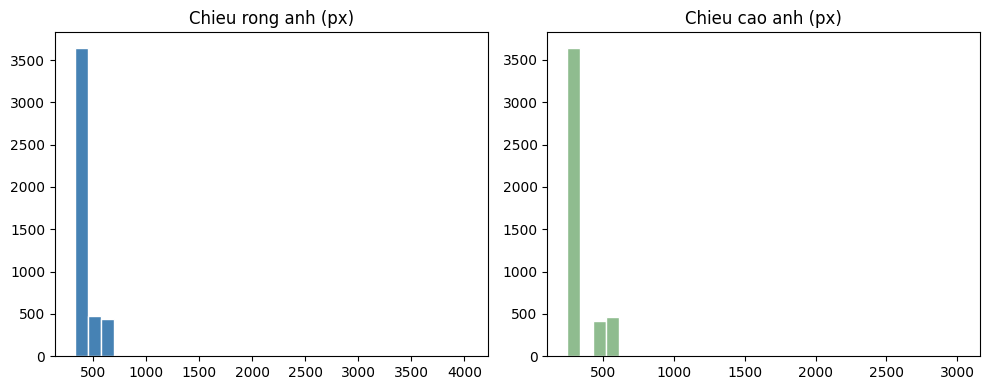

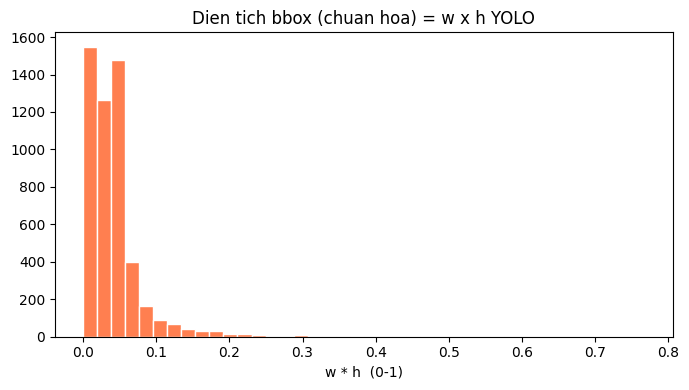

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(widths,  bins=30, color="steelblue",   edgecolor="white")
axes[0].set_title("Chieu rong anh (px)")
axes[1].hist(heights, bins=30, color="darkseagreen", edgecolor="white")
axes[1].set_title("Chieu cao anh (px)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rel_areas, bins=40, color="coral", edgecolor="white")
ax.set_title("Dien tich bbox (chuan hoa) = w x h YOLO")
ax.set_xlabel("w * h  (0-1)")
plt.tight_layout()
plt.show()

---
## Ô 5 — Lưới ảnh ngẫu nhiên kèm bounding box (kiểm tra nhãn bằng mắt)

### Mục đích

Đây là bước **kiểm tra chất lượng nhãn** (quality check / sanity check): nhìn bằng mắt để phát hiện:
- Box bị vẽ sai vị trí (lệch, quá lớn/nhỏ).
- Box thừa hoặc thiếu (một biển số không được đánh dấu).
- Ảnh quá mờ / tối / bị che mà vẫn còn trong dataset.

### Thuật toán `draw_boxes`

```
Input: img_bgr (H×W×3 numpy array), boxes (list tuple), W, H
For each (cls, xc, yc, w, h) in boxes:
    (x1,y1,x2,y2) = yolo_to_xyxy_pixel(...)    ← đổi toạ độ chuẩn hoá → pixel
    cv2.rectangle(out, (x1,y1), (x2,y2), (0,255,0), 2)  ← vẽ viền xanh lá
```

**Màu `(0, 255, 0)`** là màu xanh lá trong hệ BGR (Blue=0, Green=255, Red=0).

### Lấy mẫu cố định — `random.Random(seed=42)`

Dùng `random.Random(42).sample(list, k)` thay vì `random.sample()` toàn cục để:
- Kết quả **tái lập được** (luôn hiện cùng 16 ảnh mỗi lần chạy notebook).
- Không ảnh hưởng đến `random.seed` của phần khác trong chương trình.

### Chuyển màu BGR → RGB

OpenCV đọc ảnh theo thứ tự **BGR** (Blue-Green-Red), nhưng `matplotlib.imshow` hiển thị theo **RGB**. Nếu không chuyển, màu đỏ và xanh sẽ bị đảo.

```python
vis_rgb = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)
```

### Đọc kết quả

Chạy ô này và nhìn 16 ảnh. Box màu xanh lá nên:
- Bao quanh **đúng vùng biển số** (không thừa không thiếu).
- Có kích thước hợp lý so với ảnh.
- Nếu thấy box lệch → cần mở lại LabelImg để sửa nhãn.

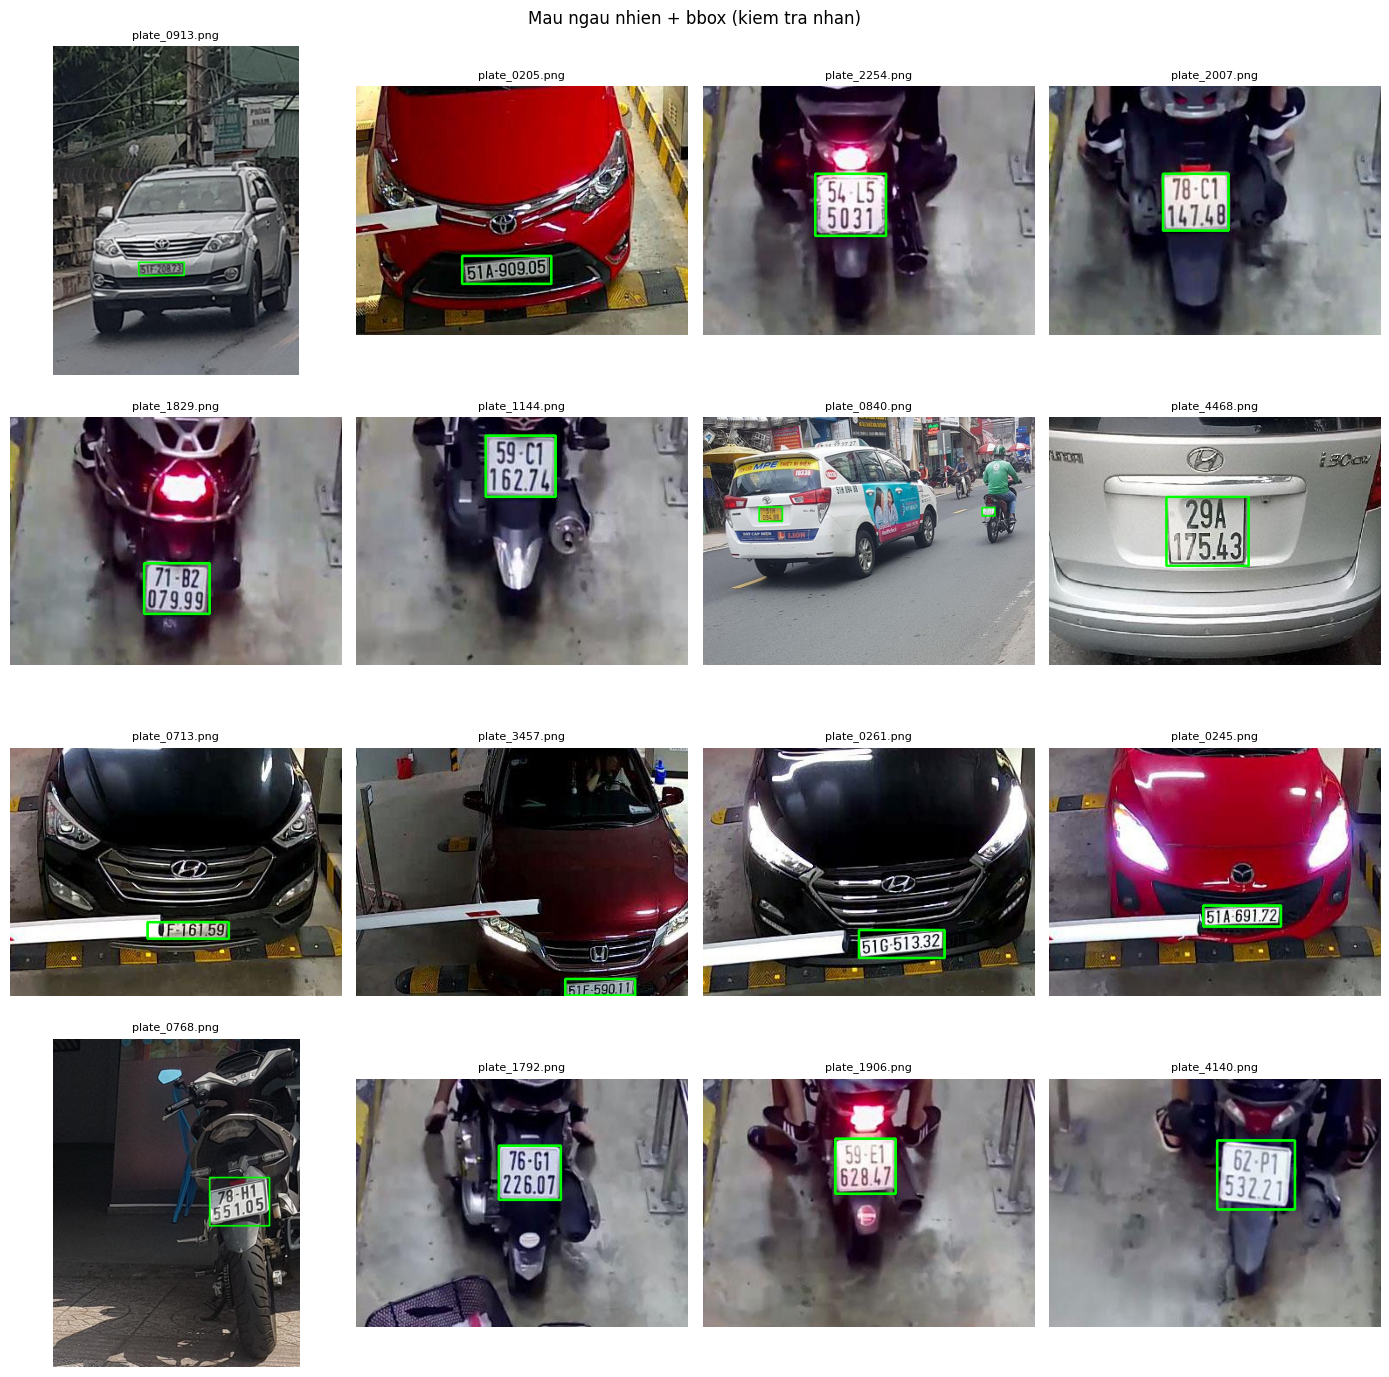

In [5]:
def draw_boxes(img_bgr, boxes, W, H):
    out = img_bgr.copy()
    for _, xc, yc, w, h in boxes:
        x1, y1, x2, y2 = yolo_to_xyxy_pixel(xc, yc, w, h, W, H)
        p1 = (int(round(x1)), int(round(y1)))
        p2 = (int(round(x2)), int(round(y2)))
        cv2.rectangle(out, p1, p2, (0, 255, 0), 2)
    return out


rng    = random.Random(42)
sample = rng.sample(images_with_label, min(16, len(images_with_label)))
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.ravel()
for ax, p in zip(axes, sample):
    img = cv2.imdecode(np.fromfile(p, dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        ax.axis("off"); continue
    H, W = img.shape[:2]
    txt  = (LBL_DIR / f"{p.stem}.txt").read_text(encoding="utf-8", errors="replace")
    boxes = parse_yolo_lines(txt)
    vis   = draw_boxes(img, boxes, W, H)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(p.name, fontsize=8)
    ax.axis("off")
for j in range(len(sample), len(axes)):
    axes[j].axis("off")
plt.suptitle("Mau ngau nhien + bbox (kiem tra nhan)", fontsize=12)
plt.tight_layout()
plt.show()

---
## Ô 6 — Kiểm tra tính nhất quán của splits (train / val / test)

### Mục đích (plan buổi 2 mục 5.2)

Sau khi tạo file `splits/*.txt`, cần xác nhận:
1. Mỗi đường dẫn ảnh trong split **thực sự tồn tại** trên đĩa.
2. Mỗi ảnh trong split **có file nhãn `.txt` tương ứng** — nếu không thì YOLO sẽ bỏ qua mẫu đó khi train.

### Hàm `verify_split`

```
Input: path đến train.txt / val.txt / test.txt
For each line (đường dẫn tương đối từ ROOT):
    - Resolve thành đường dẫn tuyệt đối
    - Kiểm tra file ảnh tồn tại → ok_img += 1
    - Kiểm tra ROOT/data/labels/raw/<stem>.txt tồn tại → ok_lbl += 1
Output: (ok_img, ok_lbl)
```

**Dấu hiệu split tốt:** `ok_img == ok_lbl == tong_dong` — tất cả ảnh tồn tại và đều có nhãn.

### Kết quả mong đợi

```
train.txt: 3204 dong   anh_ton_tai=3204   nhan_ton_tai=3204   ✓
val.txt  :  915 dong   anh_ton_tai= 915   nhan_ton_tai= 915   ✓
test.txt :  459 dong   anh_ton_tai= 459   nhan_ton_tai= 459   ✓
```

Tỉ lệ split: **70 / 20 / 10** (train / val / test) — tạo bởi `src/detector/prepare_splits.py`.

> Nếu `anh_ton_tai < tong_dong`: có đường dẫn sai (ảnh bị xoá hoặc di chuyển). Chạy lại `prepare_splits.py`.  
> Nếu `nhan_ton_tai < anh_ton_tai`: có ảnh chưa được gán nhãn lọt vào split. Cần gán nhãn thêm.

In [6]:
def verify_split(path: Path) -> tuple[int, int]:
    ok_img = ok_lbl = 0
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        ip = (ROOT / line).resolve()
        if ip.is_file():
            ok_img += 1
        lp = LBL_DIR / f"{ip.stem}.txt"
        if lp.is_file():
            ok_lbl += 1
    return ok_img, ok_lbl


for name in ("train.txt", "val.txt", "test.txt"):
    sp = SPLITS / name
    if not sp.is_file():
        print(f"Thieu {sp}")
        continue
    ni, nl = verify_split(sp)
    lines  = sum(1 for L in sp.read_text().splitlines() if L.strip())
    print(f"{name}: {lines} dong  anh_ton_tai={ni}  nhan_ton_tai={nl}")

train.txt: 3204 dong  anh_ton_tai=3204  nhan_ton_tai=3204
val.txt: 915 dong  anh_ton_tai=915  nhan_ton_tai=915
test.txt: 459 dong  anh_ton_tai=459  nhan_ton_tai=459


---
## Ô 7 — Làm sạch dữ liệu (cleaning)

### Mục tiêu

- **File nhãn mồ côi**: `.txt` trong `labels/raw` nhưng không có ảnh cùng `stem` → nên xóa hoặc bổ sung ảnh.
- **Nhãn rỗng**: file `.txt` không có dòng bbox hợp lệ → YOLO không học được từ ảnh đó.
- **Dòng sai định dạng**: thiếu cột (không đủ `class xc yc w h`) → cần sửa tay hoặc script.

Kết quả in ra dưới đây dùng để **checklist** trước khi `prepare_splits` / train.


In [7]:
# Orphan: file .txt khong co anh cung stem
image_stems = {p.stem for p in all_images}
orphan_label_files = sorted(
    p for p in LBL_DIR.glob("*.txt") if p.stem not in image_stems
)
print(f"File nhan orphan (co .txt, khong co anh): {len(orphan_label_files)}")
if orphan_label_files:
    print("  Vi du:", [x.name for x in orphan_label_files[:8]])

# Nhan rong hoac khong parse duoc bbox
empty_label_stems: list[str] = []
bad_format_lines = 0
for stem in sorted(labeled_stems & image_stems):
    lp = LBL_DIR / f"{stem}.txt"
    raw = lp.read_text(encoding="utf-8", errors="replace")
    boxes = parse_yolo_lines(raw)
    if not boxes:
        empty_label_stems.append(stem)
    for line in raw.splitlines():
        s = line.strip()
        if not s or s.startswith("#"):
            continue
        if len(s.split()) < 5:
            bad_format_lines += 1

print(f"Nhan rong (0 bbox hop le): {len(empty_label_stems)}")
if empty_label_stems:
    print("  Vi du stem:", empty_label_stems[:8])
print(f"Dong trong file nhan khong du 5 cot (can kiem tra): {bad_format_lines}")


File nhan orphan (co .txt, khong co anh): 0
Nhan rong (0 bbox hop le): 0
Dong trong file nhan khong du 5 cot (can kiem tra): 0


---
## Ô 8 — Cân bằng & phân bố (splits + số bbox/ảnh)

### Cân bằng ở bài toán detection 1 class

- **Theo split**: kiểm tra tỷ lệ **train / val / test** (mặc định dự án ~70/20/10) để không lệch tập kiểm tra.
- **Theo độ khó ngầm**: phân bố **số bbox trên mỗi ảnh** (1, 2, 3…) — nếu gần như chỉ có ảnh 1 biển, mô hình có thể kém khi test ảnh nhiều biển.
- **Hành động gợi ý**: nếu thiếu ảnh đêm / xa / nhiều biển → **thu thập thêm** đúng nhóm đó thay vì oversampling máy móc (với YOLO thường ưu tiên dữ liệu thật).


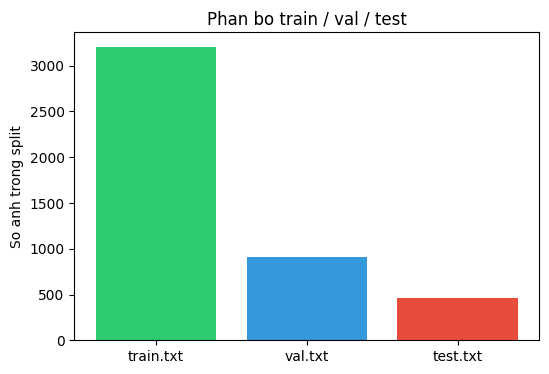

train.txt: 3204 (70.0%)
val.txt: 915 (20.0%)
test.txt: 459 (10.0%)


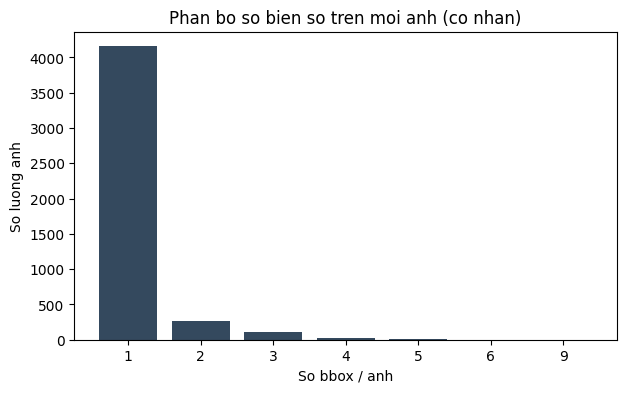

In [8]:
split_files = ("train.txt", "val.txt", "test.txt")
counts: dict[str, int] = {}
for name in split_files:
    sp = SPLITS / name
    if sp.is_file():
        counts[name] = sum(1 for L in sp.read_text(encoding="utf-8").splitlines() if L.strip())
    else:
        counts[name] = 0

labels = list(counts.keys())
values = [counts[k] for k in labels]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, values, color=["#2ecc71", "#3498db", "#e74c3c"])
ax.set_ylabel("So anh trong split")
ax.set_title("Phan bo train / val / test")
plt.show()

tot = sum(values) or 1
for k in labels:
    print(f"{k}: {counts[k]} ({100 * counts[k] / tot:.1f}%)")

# Phan bo so bbox / anh (da tinh o tren)
bc = Counter(plates_per_image)
xs = sorted(bc.keys())
ys = [bc[x] for x in xs]
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.bar([str(x) for x in xs], ys, color="#34495e")
ax2.set_xlabel("So bbox / anh")
ax2.set_ylabel("So luong anh")
ax2.set_title("Phan bo so bien so tren moi anh (co nhan)")
plt.show()


---
## Ô 9 — Augmentation & tiền xử lý (module chạy được)

Code thực tế nằm trong **`src/preprocess/image_utils.py`** (resize, chỉnh sáng/tương phản, xoay nhẹ). Script demo CLI: `python -m src.preprocess.debug_augment_demo`.

Ô dưới đây **import trực tiếp** từ package `src` (sau khi thêm `ROOT` vào `sys.path`) để báo cáo có **ảnh so sánh** gốc vs biến thể.


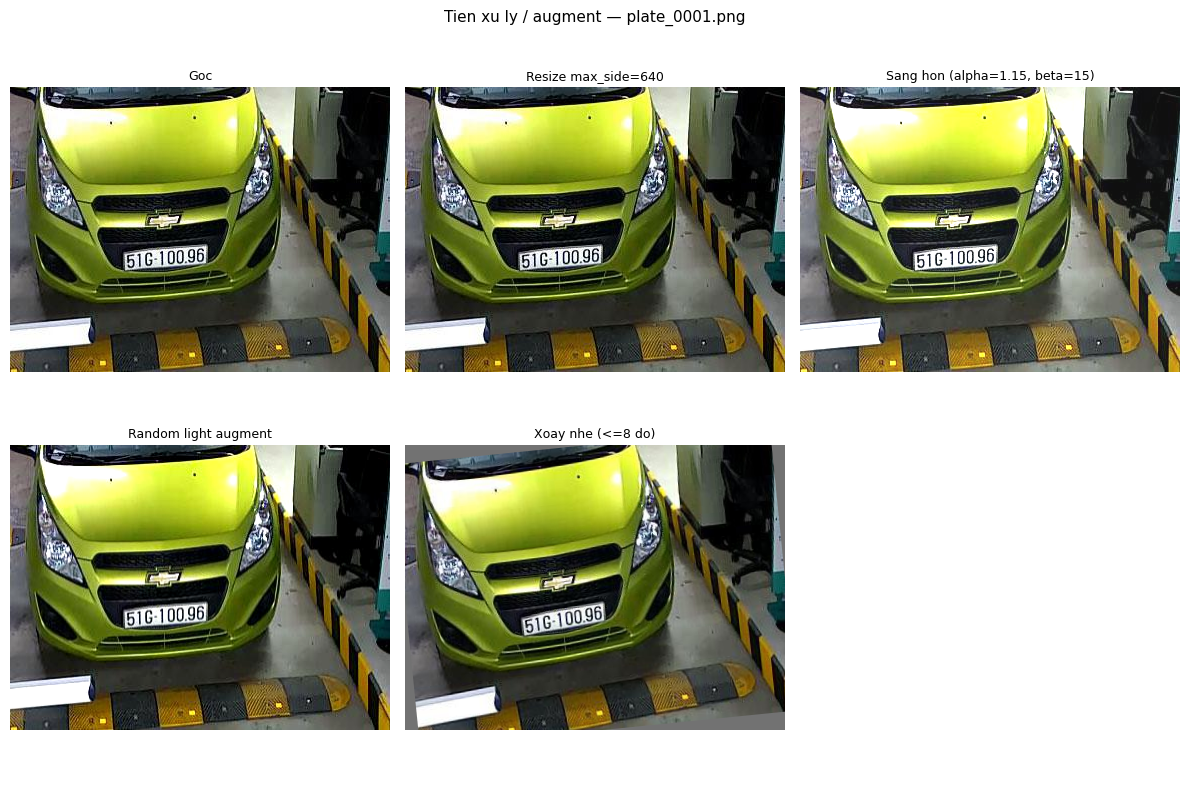

Module: D:\ComputerVisionPj\src\preprocess\image_utils.py
Chay CLI: python -m src.preprocess.debug_augment_demo


In [9]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocess.image_utils import (
    load_image_bgr,
    resize_to_max_side,
    adjust_brightness_contrast,
    random_light_augment,
    random_small_rotation,
)

demo_path = images_with_label[0]
img = load_image_bgr(demo_path)
rng_aug = np.random.default_rng(42)

variants = [
    ("Goc", img),
    ("Resize max_side=640", resize_to_max_side(img.copy(), 640)),
    ("Sang hon (alpha=1.15, beta=15)", adjust_brightness_contrast(img, alpha=1.15, beta=15)),
    ("Random light augment", random_light_augment(img, rng=rng_aug)),
    ("Xoay nhe (<=8 do)", random_small_rotation(img, max_abs_deg=8.0, rng=rng_aug)),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for ax, (title, im) in zip(axes, variants):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=9)
    ax.axis("off")
for j in range(len(variants), len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Tien xu ly / augment — {demo_path.name}", fontsize=11)
plt.tight_layout()
plt.show()

print("Module:", ROOT / "src" / "preprocess" / "image_utils.py")
print("Chay CLI: python -m src.preprocess.debug_augment_demo")


---
## (Tuỳ chọn) Gán tag đa dạng cho dataset

Khi dataset lớn hơn, nên theo dõi thêm các chiều đa dạng để đánh giá mô hình công bằng hơn.

### Cách đơn giản: hậu tố trong tên file

| Hậu tố | Ý nghĩa |
|---|---|
| `_day` | Chụp ban ngày |
| `_night` | Chụp ban đêm / thiếu sáng |
| `_far` | Biển số ở xa (bbox nhỏ) |
| `_near` | Biển số gần (bbox lớn) |
| `_moto` | Xe máy |
| `_car` | Ô tô |

Ví dụ: `plate_0123_night_far.png`.

### Phân tích sau khi tag

```python
tags = [p.name.split("_")[2:] for p in images_with_label]  # sau plate_XXXX_
```

Vẽ biểu đồ tần suất tag để kiểm tra dataset có cân bằng không (không quá thiếu ảnh đêm, biển xa…).

### Tại sao quan trọng?

YOLO học tốt khi data đa dạng:
- Chỉ có ảnh ngày → val/test đêm kém.
- Chỉ có ảnh gần → không nhận biển số xa.
- Chỉ có ô tô → xe máy bị bỏ sót.

Việc tag sớm giúp nhóm nhận ra thiếu hụt và thu thập thêm đúng loại ảnh cần thiết.